In [1]:
%matplotlib inline

import sys
from pathlib import Path
from datetime import datetime, timezone, timedelta

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd

from scipy.ndimage import gaussian_filter, uniform_filter1d
from scipy.signal import detrend, butter, filtfilt
from scipy.integrate import cumulative_trapezoid
from skimage.morphology import skeletonize

sys.path.append("/root/autodl-tmp")
from model import FaultCleanRule

In [2]:
EVENTS_ROOT = Path("/root/autodl-tmp/Test_on_Event/menyuan")
EVENT_NAMES = ["Menyuan"]

TRAIN_H5  = r"/root/autodl-tmp/data/data/events.h5"
CKPT_PATH = r"/root/autodl-tmp/checkpoints_pgv_aniso/pgv/best_iou_rule_hybrid.pth"

CHANNEL     = "pgv"
GRID_SIZE   = 150
RESOLUTION  = 0.01
TOTAL_DUR   = 40.0
N_TIMESTEPS = 60

MODEL_PATCH_SIZE            = 10
MODEL_D_MODEL               = 256
MODEL_N_LAYERS              = 6
MODEL_GRID_SIZE             = 150
MODEL_DECODER_DIM           = 32
MODEL_DECODER_MID_DIM       = 64
MODEL_DECODER_REFINE_BLOCKS = 3
MODEL_COMMIT_TAU            = 0.60
MODEL_COMMIT_TEMP           = 0.08
MODEL_CAUSAL                = True

PHASENET_CSV_PATTERN = '{event_name}_phasenet_picks.csv'
V_P_KM_S             = 6.0   

INTERP_SIGMA_DEG    = 0.15
INTERP_CUTOFF_SIGMA = 4.0
# INTERP_SIGMA_DEG    = 0.35
# INTERP_CUTOFF_SIGMA = 3.0

THRESHOLD        = 0.5
IGNORE_EARLY_SEC = 0.0
VOTE_WINDOW      = 1
VOTE_THRESH      = 0.5

MANUAL_ORIGIN_TIMES = {
    'Menyuan': '2022-01-07T17:45:30+00:00',
}

# recorder_time in HDF5 is CST (UTC+8)
ASSUME_CST_FOR_NAIVE_TIME = True

USE_PHYSICAL_END_TRUNCATION = True
USE_LATE_PGV_SUPPRESSION    = False

FAULT_LENGTH_A         = 0.50
FAULT_LENGTH_B         = -1.80
RUPTURE_VELOCITY_KM_S  = 3.0
MIN_RUPTURE_DURATION_S = 4.0
MAX_RUPTURE_DURATION_S = 40.0
PHYSICAL_END_BUFFER_S  = 4.0
V_S_KM_S               = 3.5

EVENT_RUPTURE_DURATION_OVERRIDES_S = {}
EVENT_EFFECTIVE_END_OVERRIDES_S    = {}

LATE_SUPPRESS_START_S   = 20.0
LATE_SUPPRESS_JUMP_SCALE = 3.0

CHANNEL_PRIORITY = ['UD', 'EW', 'NS']

In [3]:
CST = timezone(timedelta(hours=8))


def preprocess_acc_to_vel(acc, sr, pre_event_s=5.0,
                           hp_hz=0.10, lp_hz=10.0, filt_order=3):
    x = np.asarray(acc, dtype=np.float32).reshape(-1)
    if len(x) == 0:
        return x.astype(np.float32), x.astype(np.float32)
    n_pre    = min(int(pre_event_s * sr), len(x))
    baseline = float(np.median(x[:n_pre])) if n_pre > 16 else float(np.median(x))
    x        = detrend(x - baseline, type='linear').astype(np.float32)
    nyq      = 0.5 * sr
    hp       = max(hp_hz / nyq, 1e-5)
    lp       = min(lp_hz / nyq, 0.999)
    b, a     = (butter(filt_order, [hp, lp], btype='band') if hp < lp
                else butter(filt_order, hp, btype='high'))
    acc_proc = filtfilt(b, a, x).astype(np.float32)
    vel      = cumulative_trapezoid(acc_proc, dx=1.0/sr, initial=0.0).astype(np.float32)
    vel      = detrend(vel, type='linear').astype(np.float32)
    hp2      = max(0.05 / nyq, 1e-5)
    if hp2 < 0.999:
        b2, a2 = butter(2, hp2, btype='high')
        vel    = filtfilt(b2, a2, vel).astype(np.float32)
    return acc_proc, vel


def gauss_interp(lons, lats, values, grid_lon, grid_lat,
                 sigma_deg=0.06, min_active=3, cutoff_sigma=None):
    field      = np.zeros(grid_lon.shape, dtype=np.float32)
    weight_sum = np.zeros_like(field)
    active     = [(lo, la, v) for lo, la, v in zip(lons, lats, values) if v > 0]
    if len(active) < min_active:
        return field
    for lo, la, val in active:
        dist2 = (grid_lon - lo) ** 2 + (grid_lat - la) ** 2
        w     = np.exp(-dist2 / (2 * sigma_deg ** 2))
        if cutoff_sigma is not None:
            w *= (dist2 <= (cutoff_sigma * sigma_deg) ** 2).astype(np.float32)
        field      += w * val
        weight_sum += w
    mask          = weight_sum > 1e-10
    field[mask]  /= weight_sum[mask]
    return field.astype(np.float32)


def parse_event_time(value, assume_cst=True):
    if value is None:
        return None
    text = value.decode('utf-8') if isinstance(value, (bytes, np.bytes_)) else str(value)
    text = text.strip().replace('Z', '+00:00')
    if not text or text == 'UNKNOWN':
        return None
    try:
        dt = datetime.fromisoformat(text)
    except ValueError:
        return None
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=CST if assume_cst else timezone.utc)
    return dt


def resolve_origin_time(event_name, h5_origin_value, manual_times=None):
    if manual_times is not None and event_name in manual_times:
        return parse_event_time(manual_times[event_name], assume_cst=False)
    return parse_event_time(h5_origin_value, assume_cst=False)


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return float(R * 2 * np.arcsin(np.sqrt(a)))


def get_rec_offset(grp, eq_origin, dist_km, p_pick_abs):
    """
    Compute rec_offset_s = (record_start - origin_time) in seconds.

    Priority:
      1. recorder_time exists and is not UNKNOWN
         -> offset_s = recorder_time - origin_time
      2. PhaseNet pick available
         -> offset_s = p_pick_abs - dist_km / V_P_KM_S
      3. both missing -> 0.0
    """
    rec_time_raw = grp.attrs.get('recorder_time', None)
    if rec_time_raw is not None and str(rec_time_raw) not in ('UNKNOWN', ''):
        rec_time = parse_event_time(str(rec_time_raw),
                                    assume_cst=ASSUME_CST_FOR_NAIVE_TIME)
        if rec_time is not None and eq_origin is not None:
            return (rec_time - eq_origin).total_seconds()

    if p_pick_abs is not None:
        return float(p_pick_abs) - dist_km / V_P_KM_S

    return 0.0


def load_phasenet_picks(event_dir, event_name):
    csv_name = PHASENET_CSV_PATTERN.format(event_name=event_name)
    csv_path = Path(event_dir) / csv_name
    if not csv_path.exists():
        print(f'  [WARNING] PhaseNet CSV not found: {csv_path}')
        return {}
    df = pd.read_csv(csv_path, index_col='station_id')
    picks = {
        sid: (None if pd.isna(row['p_pick_s']) else float(row['p_pick_s']))
        for sid, row in df.iterrows()
    }
    n_valid = sum(1 for v in picks.values() if v is not None)
    print(f'  Loaded PhaseNet picks: {n_valid}/{len(picks)} stations')
    return picks


def magnitude_to_fault_length_km(mw):
    return float(10.0 ** (FAULT_LENGTH_A * float(mw) + FAULT_LENGTH_B))


def estimate_rupture_duration_s(mw, event_name=None, overrides=None):
    if overrides is not None and event_name in overrides:
        return float(overrides[event_name])
    length_km = magnitude_to_fault_length_km(mw)
    return float(np.clip(length_km / RUPTURE_VELOCITY_KM_S,
                          MIN_RUPTURE_DURATION_S, MAX_RUPTURE_DURATION_S))


def physical_end_in_record_seconds(effective_end_abs_s, rec_offset_s):
    return float(effective_end_abs_s - rec_offset_s)


def truncate_after_time(arr, sr, end_in_record_s):
    arr = np.asarray(arr, dtype=np.float32).reshape(-1)
    idx = int(np.ceil(end_in_record_s * sr))
    if idx < len(arr):
        arr        = arr.copy()
        arr[idx:]  = 0.0
    return arr


def estimate_t_first_trigger(dep_km, eq_lat, eq_lon,
                              lons_sta=None, lats_sta=None, v_s=V_S_KM_S):
    if lons_sta is None or len(lons_sta) == 0:
        return dep_km / v_s
    dlat  = (lats_sta - eq_lat) * 111.0
    dlon  = (lons_sta - eq_lon) * 111.0 * np.cos(np.radians(eq_lat))
    dist3 = np.sqrt(dlat**2 + dlon**2 + dep_km**2)
    return float(dist3.min() / v_s)


def pick_waveform_china(wgrp):
    for k in CHANNEL_PRIORITY:
        if k in wgrp:
            arr = np.asarray(wgrp[k][:], dtype=np.float32).reshape(-1)
            if arr.size > 0:
                return arr
    for k in wgrp.keys():
        arr = np.asarray(wgrp[k][:], dtype=np.float32).reshape(-1)
        if arr.size > 0:
            return arr
    return None

In [4]:
def build_monotonic_station_pgv(stations, times, win_s=2.0):
    times = np.asarray(times, dtype=np.float32)
    out   = np.zeros((len(times), len(stations)), dtype=np.float32)
    for j, s in enumerate(stations):
        vel          = np.asarray(s['waveform'], dtype=np.float32).reshape(-1)
        sr           = float(s['sr'])
        rec_offset_s = float(s.get('rec_offset_s', 0.0))
        if len(vel) == 0 or sr <= 0:
            continue
        abs_vel = np.abs(vel)
        win_n   = max(1, int(round(win_s * sr)))
        cur_max = 0.0
        for k, t_abs in enumerate(times):
            t_rec = float(t_abs) - rec_offset_s
            if t_rec <= 0:
                out[k, j] = cur_max
                continue
            i1 = int(np.clip(np.ceil(t_rec * sr), 0, len(abs_vel)))
            if i1 <= 0:
                out[k, j] = cur_max
                continue
            i0      = max(0, i1 - win_n)
            cur_max = max(cur_max, float(abs_vel[i0:i1].max()) if i1 > i0 else 0.0)
            out[k, j] = cur_max
    return out


def suppress_late_pgv_jumps(station_pgv_cum, times,
                             late_start_s=20.0, jump_scale=2.0, min_ref=1e-6):
    result = np.asarray(station_pgv_cum, dtype=np.float32).copy()
    if result.ndim != 2 or result.shape[0] < 2:
        return result
    inc       = np.diff(result, axis=0)
    t_mid     = times[1:]
    early_mask = (t_mid >= 0.0) & (t_mid < late_start_s)
    if early_mask.sum() == 0:
        return result
    ref = np.maximum(
        np.percentile(inc[early_mask], 95, axis=0).astype(np.float32) * jump_scale,
        min_ref)
    for t in np.where(t_mid >= late_start_s)[0] + 1:
        delta      = result[t] - result[t - 1]
        result[t]  = result[t - 1] + np.minimum(delta, ref)
    return result


def sliding_window_vote(pred_binary, win=5, thresh=0.5):
    x = np.asarray(pred_binary, dtype=np.float32)
    if x.ndim != 3:
        raise ValueError(f'pred_binary must be [T,H,W], got {x.shape}')
    if win <= 1:
        return (x > 0.5).astype(np.uint8)
    avg = uniform_filter1d(x, size=win, axis=0, mode='nearest')
    return (avg >= thresh).astype(np.uint8)


def skeleton_to_polyline(skel):
    skel   = np.asarray(skel, dtype=bool)
    ys, xs = np.where(skel)
    if len(xs) == 0:
        return np.empty((0, 2), dtype=np.float32)
    pixels = set(zip(ys.tolist(), xs.tolist()))

    def neighbors(p):
        y, x = p
        return [(y+dy, x+dx) for dy in (-1,0,1) for dx in (-1,0,1)
                if not (dy==0 and dx==0) and (y+dy, x+dx) in pixels]

    visited, comps = set(), []
    for p in pixels:
        if p in visited:
            continue
        stack, comp = [p], []
        visited.add(p)
        while stack:
            cur = stack.pop()
            comp.append(cur)
            for q in neighbors(cur):
                if q not in visited:
                    visited.add(q)
                    stack.append(q)
        comps.append(comp)

    comp     = max(comps, key=len)
    comp_set = set(comp)

    def comp_neighbors(p):
        y, x = p
        return [(y+dy, x+dx) for dy in (-1,0,1) for dx in (-1,0,1)
                if not (dy==0 and dx==0) and (y+dy, x+dx) in comp_set]

    deg       = {p: len(comp_neighbors(p)) for p in comp}
    endpoints = [p for p, d in deg.items() if d == 1]
    start     = endpoints[0] if endpoints else comp[0]
    ordered   = [start]
    used      = {start}
    prev, cur = None, start
    while True:
        cand = [q for q in comp_neighbors(cur) if q != prev and q not in used]
        if not cand:
            break
        if prev is not None and len(cand) > 1:
            vy   = cur[0] - prev[0]
            vx   = cur[1] - prev[1]
            cand = sorted(cand,
                          key=lambda q: vy*(q[0]-cur[0]) + vx*(q[1]-cur[1]),
                          reverse=True)
        nxt = cand[0]
        ordered.append(nxt)
        used.add(nxt)
        prev, cur = cur, nxt
    return np.array([(x, y) for y, x in ordered], dtype=np.float32)

In [5]:
with h5py.File(TRAIN_H5, 'r') as f:
    ng = f['normalization_diff']
    if CHANNEL == 'pgv':
        DIFF_MEAN = float(ng.attrs['dpgv_mean'])
        DIFF_STD  = float(ng.attrs['dpgv_std'])
    elif CHANNEL == 'pga':
        DIFF_MEAN = float(ng.attrs['dpga_mean'])
        DIFF_STD  = float(ng.attrs['dpga_std'])
    else:
        DIFF_MEAN = float(ng.attrs['dint_mean'])
        DIFF_STD  = float(ng.attrs['dint_std'])

print(f'DIFF_MEAN={DIFF_MEAN:.6f}  DIFF_STD={DIFF_STD:.6f}')

DIFF_MEAN=1.044808  DIFF_STD=3.473895


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt      = torch.load(CKPT_PATH, map_location=device)
ckpt_args = ckpt.get('args', {}) if isinstance(ckpt, dict) else {}

def get_ckpt_arg(name, default):
    return ckpt_args.get(name, default) if isinstance(ckpt_args, dict) else default

model = FaultCleanRule(
    in_channels=1,
    patch_size=int(get_ckpt_arg('patch_size', MODEL_PATCH_SIZE)),
    d_model=int(get_ckpt_arg('d_model', MODEL_D_MODEL)),
    n_layers=int(get_ckpt_arg('n_layers', MODEL_N_LAYERS)),
    grid_size=int(get_ckpt_arg('grid_size', MODEL_GRID_SIZE)),
    decoder_dim=int(get_ckpt_arg('decoder_dim', MODEL_DECODER_DIM)),
    decoder_mid_dim=int(get_ckpt_arg('decoder_mid_dim', MODEL_DECODER_MID_DIM)),
    decoder_refine_blocks=int(get_ckpt_arg('decoder_refine_blocks', MODEL_DECODER_REFINE_BLOCKS)),
    causal=bool(get_ckpt_arg('causal', MODEL_CAUSAL)),
    commit_tau=float(get_ckpt_arg('commit_tau', MODEL_COMMIT_TAU)),
    commit_temp=float(get_ckpt_arg('commit_temp', MODEL_COMMIT_TEMP)),
).to(device)

state = ckpt['model'] if isinstance(ckpt, dict) and 'model' in ckpt else ckpt
if len(state) > 0 and all(k.startswith('module.') for k in state.keys()):
    state = {k.replace('module.', '', 1): v for k, v in state.items()}

model.load_state_dict(state, strict=True)
model.eval()
print(f'Model loaded on {device}')

Model loaded on cuda


In [7]:
def run_single_event(event_dir, model, device, diff_mean, diff_std):
    event_dir = Path(event_dir)
    name      = event_dir.name

    h5_files = list(event_dir.glob('*.h5'))
    if not h5_files:
        print(f'[{name}] no .h5 file found')
        return None
    h5_path = h5_files[0]

    # load PhaseNet picks from CSV
    phasenet_picks = load_phasenet_picks(event_dir, name)

    with h5py.File(h5_path, 'r') as f:
        eq       = f['earthquake']
        sta_root = f['stations']

        EQ_MAG = float(eq.attrs.get('magnitude', 0.0))
        EQ_DEP = float(eq.attrs.get('depth', 10.0))
        EQ_LAT = float(eq.attrs.get('latitude', 0.0))
        EQ_LON = float(eq.attrs.get('longitude', 0.0))

        eq_origin = resolve_origin_time(
            name, eq.attrs.get('origin_time', None), MANUAL_ORIGIN_TIMES)

        rupture_duration_s  = estimate_rupture_duration_s(
            EQ_MAG, event_name=name,
            overrides=EVENT_RUPTURE_DURATION_OVERRIDES_S)
        effective_end_abs_s = EVENT_EFFECTIVE_END_OVERRIDES_S.get(
            name, rupture_duration_s + PHYSICAL_END_BUFFER_S)

        stations = []

        for sta_id in sta_root.keys():
            g = sta_root[sta_id]
            if 'waveforms' not in g:
                continue

            acc_raw = pick_waveform_china(g['waveforms'])
            if acc_raw is None or len(acc_raw) == 0:
                continue

            lon = float(g.attrs.get('longitude', 0.0))
            lat = float(g.attrs.get('latitude',  0.0))
            sr  = float(g.attrs.get('sampling_rate', 100.0))

            # PhaseNet P-pick (relative to origin time)
            p_pick_abs = phasenet_picks.get(sta_id, None)

            # compute distance for fallback
            dist_km = haversine_km(EQ_LAT, EQ_LON, lat, lon)

            # rec_offset_s: recorder_time preferred, PhaseNet fallback
            rec_offset_s = get_rec_offset(g, eq_origin, dist_km, p_pick_abs)

            # t_offset: position of P-pick within the record (seconds)
            if p_pick_abs is not None:
                t_in_rec = float(p_pick_abs) - rec_offset_s
            else:
                t_in_rec = np.inf   # station not triggered

            acc_proc, vel = preprocess_acc_to_vel(acc_raw, sr=sr)

            end_in_record_s  = physical_end_in_record_seconds(
                effective_end_abs_s, rec_offset_s)
            waveform_for_pgv = (
                truncate_after_time(vel, sr, end_in_record_s)
                if USE_PHYSICAL_END_TRUNCATION else vel.copy()
            )

            stations.append({
                'name':               sta_id,
                'lon':                lon,
                'lat':                lat,
                'sr':                 sr,
                't_offset':           t_in_rec,
                'rec_offset_s':       rec_offset_s,
                'effective_end_abs_s': effective_end_abs_s,
                'end_in_record_s':    end_in_record_s,
                'acc':                acc_proc,
                'vel':                vel,
                'waveform':           waveform_for_pgv,
            })

    half    = GRID_SIZE * RESOLUTION * 0.5
    lon_min = EQ_LON - half;  lon_max = EQ_LON + half
    lat_min = EQ_LAT - half;  lat_max = EQ_LAT + half

    stations = [s for s in stations
                if lon_min <= s['lon'] <= lon_max
                and lat_min <= s['lat'] <= lat_max]

    print(f'[{name}] stations in grid: {len(stations)}  '
          f'M{EQ_MAG} dep={EQ_DEP}km  rup_dur={rupture_duration_s:.1f}s')

    if len(stations) == 0:
        print(f'[{name}] no stations in grid, skipping')
        return None

    lons_sta = np.asarray([s['lon'] for s in stations], dtype=np.float32)
    lats_sta = np.asarray([s['lat'] for s in stations], dtype=np.float32)

    t_first_trigger_s = estimate_t_first_trigger(
        EQ_DEP, EQ_LAT, EQ_LON, lons_sta, lats_sta, v_s=V_S_KM_S)

    times_abs = np.linspace(0.0, TOTAL_DUR, N_TIMESTEPS, dtype=np.float32)

    station_pgv_cum = build_monotonic_station_pgv(stations, times_abs)
    if USE_LATE_PGV_SUPPRESSION:
        station_pgv_cum = suppress_late_pgv_jumps(
            station_pgv_cum, times_abs,
            late_start_s=LATE_SUPPRESS_START_S,
            jump_scale=LATE_SUPPRESS_JUMP_SCALE)

    grid_lons = np.linspace(lon_min, lon_max, GRID_SIZE, dtype=np.float32)
    grid_lats = np.linspace(lat_min, lat_max, GRID_SIZE, dtype=np.float32)
    grid_lon, grid_lat = np.meshgrid(grid_lons, grid_lats)

    pgv_fields = []
    for k in range(N_TIMESTEPS):
        pgv_vals = station_pgv_cum[k]
        field    = gauss_interp(
            lons_sta, lats_sta, pgv_vals,
            grid_lon, grid_lat,
            sigma_deg=INTERP_SIGMA_DEG,
            cutoff_sigma=INTERP_CUTOFF_SIGMA)
        pgv_fields.append(field)

    pgv_fields = np.stack(pgv_fields, axis=0)   # [T, H, W]
    dpgv       = np.diff(pgv_fields, axis=0, prepend=pgv_fields[:1])
    dpgv       = np.maximum(dpgv, 0.0)
    valid_mask = times_abs >= (t_first_trigger_s + IGNORE_EARLY_SEC)
    valid_idx  = np.where(valid_mask)[0]
    print(f'pgv_fields max: {pgv_fields.max():.4f}')
    print(f'pgv_fields at center (75,75): {pgv_fields[:, 75, 75].max():.4f}')
    print(f'pgv_fields at frame 30 spatial max location: '
          f'{np.unravel_index(pgv_fields[30].argmax(), (150,150))}')
    
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    for col, fi in enumerate(np.linspace(0, len(times_abs)-1, 5, dtype=int)):
        im = axes[col].imshow(pgv_fields[fi], cmap='hot', origin='lower')
        axes[col].set_title(f'PGV t={times_abs[fi]:.1f}s\nmax={pgv_fields[fi].max():.3f}')
        plt.colorbar(im, ax=axes[col])
    plt.tight_layout()
    plt.show()
    if len(valid_idx) == 0:
        return None

    dpgv_norm = (dpgv[valid_idx] - diff_mean) / (diff_std + 1e-8)
    inputs_t  = torch.from_numpy(
        dpgv_norm[np.newaxis, np.newaxis]).float().to(device)
    times_mid = times_abs[valid_idx].astype(np.float32)
    times_t   = torch.from_numpy(times_mid[np.newaxis]).float().to(device)
    seq_mask  = torch.ones(1, len(valid_idx), dtype=torch.bool, device=device)

    epi_x       = (EQ_LON - lon_min) / (lon_max - lon_min)
    epi_y       = (EQ_LAT - lat_min) / (lat_max - lat_min)
    epicenter_t = torch.tensor([[epi_x, epi_y]],
                               dtype=torch.float32, device=device)

    with torch.no_grad():
        belief_logits, committeds = model(
            inputs_t, times_t, seq_mask, epicenter_t)

    committed_prob = committeds[0].cpu().numpy()   # [T_valid, H, W]
    pred_binary    = (committed_prob > THRESHOLD).astype(np.uint8)

    preview_frames = np.where(times_mid <= effective_end_abs_s)[0]
    last_show = int(preview_frames[-1]) if len(preview_frames) > 0 \
                else len(valid_idx) - 1
    last_show = int(np.clip(last_show, 0, len(valid_idx) - 1))

    pred_sliding = sliding_window_vote(
        committed_prob, win=VOTE_WINDOW, thresh=VOTE_THRESH)

    event_dir.mkdir(parents=True, exist_ok=True)
    np.save(event_dir / 'pred_binary.npy',       pred_binary)
    np.save(event_dir / 'pred_prob.npy',          committed_prob)
    np.save(event_dir / 'pred_sliding_vote.npy',  pred_sliding)
    np.save(event_dir / 'times_mid_valid.npy',    times_mid)
    np.savez(
        event_dir / 'event_metadata.npz',
        eq_lat=np.float32(EQ_LAT),
        eq_lon=np.float32(EQ_LON),
        eq_mag=np.float32(EQ_MAG),
        eq_dep=np.float32(EQ_DEP),
        lon_min=np.float32(lon_min),
        lon_max=np.float32(lon_max),
        lat_min=np.float32(lat_min),
        lat_max=np.float32(lat_max),
        t_first_trigger_s=np.float32(t_first_trigger_s),
        effective_end_abs_s=np.float32(effective_end_abs_s),
        effective_end_inf_s=np.float32(max(0.0, effective_end_abs_s - t_first_trigger_s)),
        rupture_duration_s=np.float32(rupture_duration_s),
    )

    # quick preview
    n_show   = min(10, len(valid_idx))
    show_idx = np.linspace(0, last_show, n_show, dtype=int)

    fig, axes = plt.subplots(2, n_show, figsize=(3*n_show, 6))
    for col, fi in enumerate(show_idx):
        axes[0, col].imshow(committed_prob[fi], vmin=0, vmax=1,
                            cmap='hot', origin='lower')
        axes[0, col].set_title(f't={times_mid[fi]:.1f}s', fontsize=7)
        axes[0, col].axis('off')
        axes[1, col].imshow(pred_binary[fi], vmin=0, vmax=1,
                            cmap='gray', origin='lower')
        axes[1, col].axis('off')
    axes[0, 0].set_ylabel('prob',   fontsize=8)
    axes[1, 0].set_ylabel('binary', fontsize=8)
    fig.suptitle(f'{name}  |  Mw{EQ_MAG}  |  {len(stations)} stations',
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(event_dir / 'preview.png', dpi=120, bbox_inches='tight')
    plt.show()

    return pred_binary


Processing: Menyuan
  Loaded PhaseNet picks: 60/60 stations
[Menyuan] stations in grid: 60  M6.9 dep=10.0km  rup_dur=14.9s
pgv_fields max: 9.8351
pgv_fields at center (75,75): 8.3685
pgv_fields at frame 30 spatial max location: (np.int64(85), np.int64(61))


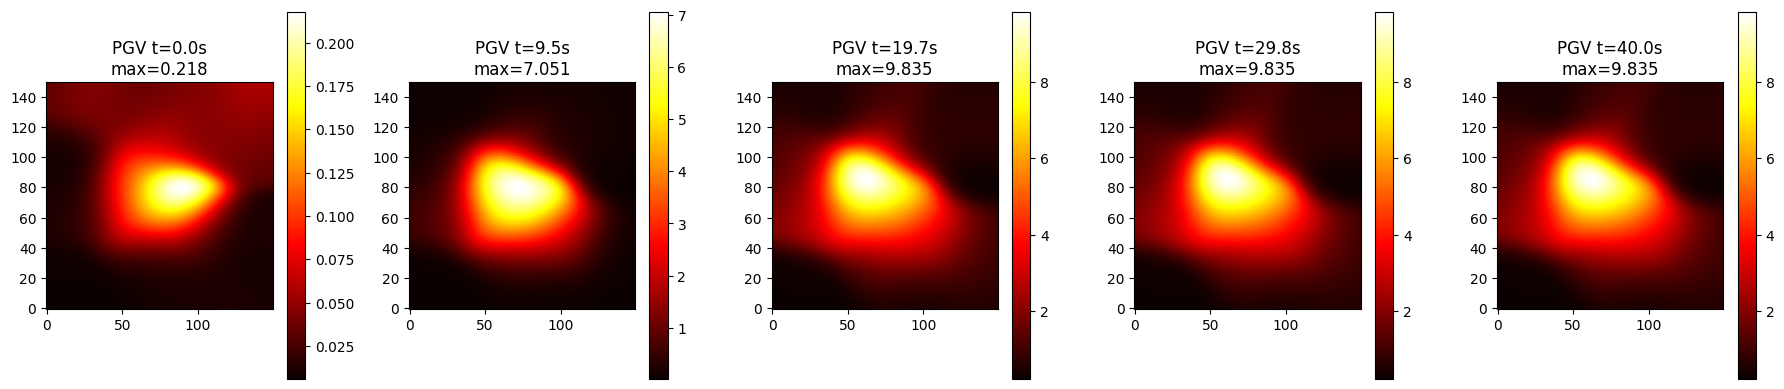

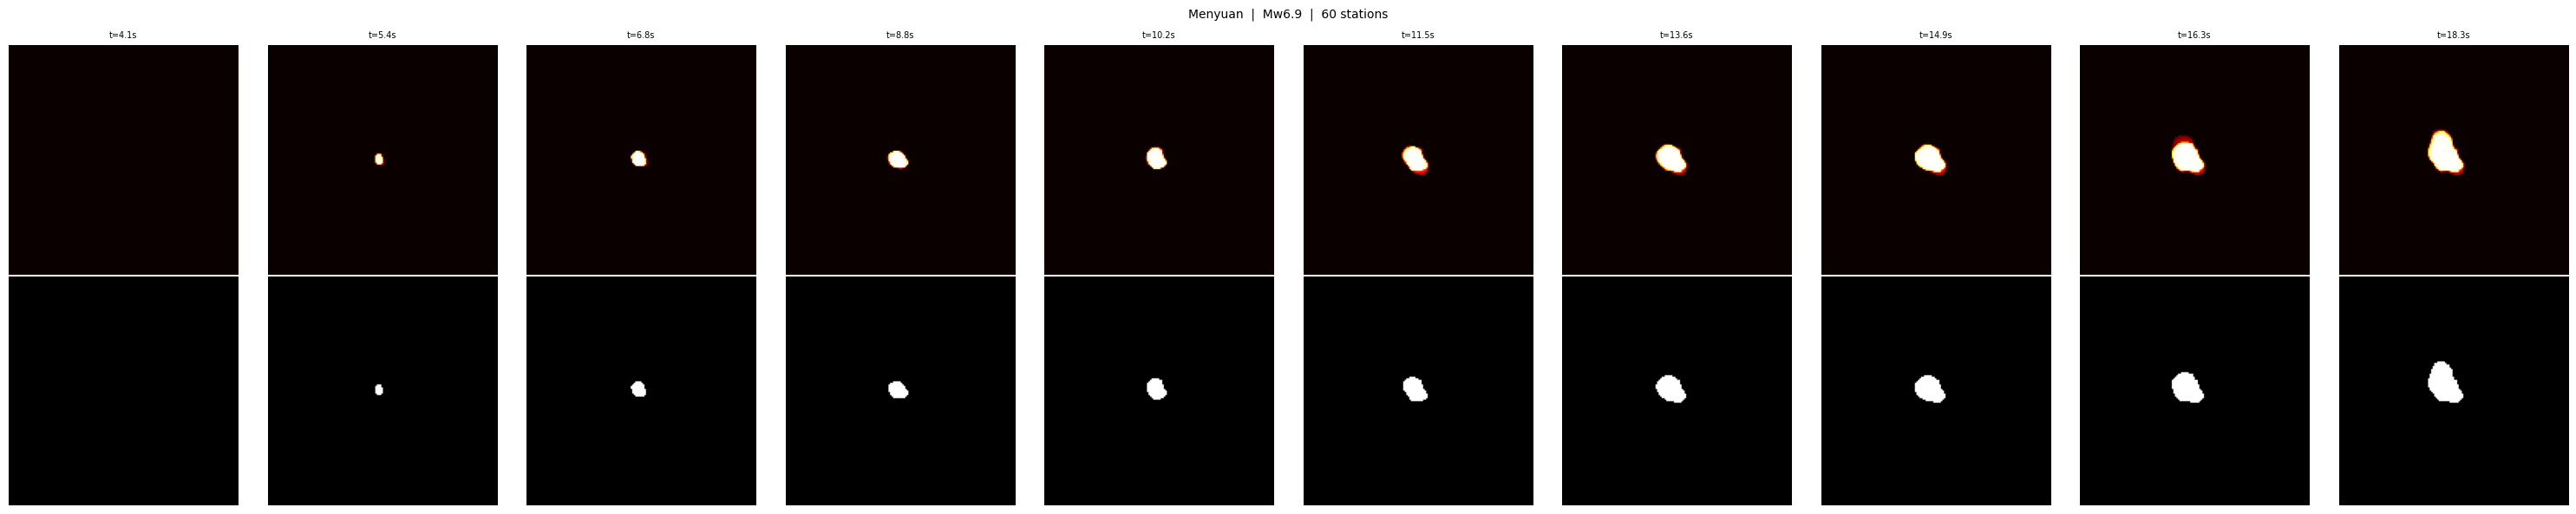

  Done. pred_binary shape: (54, 150, 150)


In [8]:
results = {}

for event_name in EVENT_NAMES:
    event_dir = EVENTS_ROOT / event_name
    if not event_dir.is_dir():
        print(f'[SKIP] {event_name}: directory not found')
        continue
    print(f'\nProcessing: {event_name}')
    pred_binary = run_single_event(
        event_dir, model, device, DIFF_MEAN, DIFF_STD)
    if pred_binary is not None:
        results[event_name] = pred_binary
        print(f'  Done. pred_binary shape: {pred_binary.shape}')
    else:
        print(f'  [FAILED] {event_name}')